In [1]:
# File: 02_train_classifier.ipynb

import os
import torch

from common import device, print_device, set_seed
from classifier_lib import (
    MNISTCNN,
    get_classifier_loaders,
    train_classifier,
    save_classifier_checkpoint,
    load_classifier_checkpoint,
    classify_and_show_raw,
)

print_device()

device: cuda
GPU Name: NVIDIA L40S


In [2]:
#
SEED = 2026
set_seed(SEED)

ROOT = "./data"
BATCH_SIZE = 64
CLF_EPOCHS = 5


Seed set to: 2026


In [ ]:
# Keep this equal to the space the classifier notebook actually used.
INPUT_SPACE = "01_norm"   
CLF_CKPT_PATH = f"classifier_{INPUT_SPACE}.pt"


In [4]:
#
train_ds, test_ds, train_loader, test_loader = get_classifier_loaders(
    root=ROOT,
    batch_size=BATCH_SIZE,
    input_space=INPUT_SPACE,
)

clf = MNISTCNN().to(device)


In [5]:
#
clf = train_classifier(
    model=clf,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=CLF_EPOCHS,
    lr=1e-3,
    weight_decay=1e-4,
    device=device,
)


[CLF] Epoch 1/5: 100%|██████████| 938/938 [00:05<00:00, 156.91it/s, loss=0.0751]


[CLF] Epoch 1: loss=0.0751 | test_acc=98.66%


[CLF] Epoch 2/5: 100%|██████████| 938/938 [00:05<00:00, 165.96it/s, loss=0.0476]


[CLF] Epoch 2: loss=0.0476 | test_acc=99.20%


[CLF] Epoch 3/5: 100%|██████████| 938/938 [00:05<00:00, 167.86it/s, loss=0.0507]


[CLF] Epoch 3: loss=0.0507 | test_acc=99.03%


[CLF] Epoch 4/5: 100%|██████████| 938/938 [00:05<00:00, 164.93it/s, loss=0.0348]


[CLF] Epoch 4: loss=0.0348 | test_acc=99.32%


[CLF] Epoch 5/5: 100%|██████████| 938/938 [00:05<00:00, 167.43it/s, loss=0.0245]


[CLF] Epoch 5: loss=0.0245 | test_acc=99.24%


In [6]:
#
save_classifier_checkpoint(
    path=CLF_CKPT_PATH,
    model=clf,
    input_space=INPUT_SPACE,
)
print("saved:", CLF_CKPT_PATH)


saved: classifier_01_norm.pt


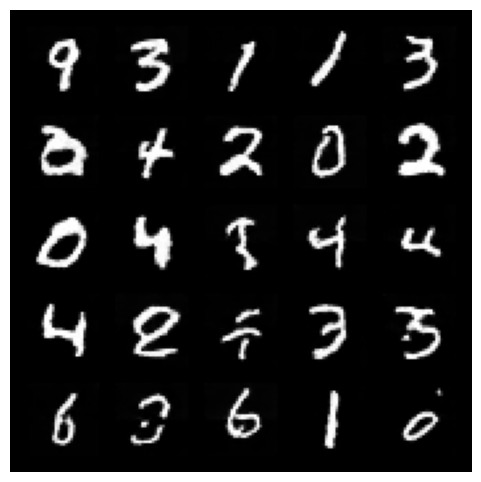

preds: [9, 3, 1, 1, 3, 0, 4, 2, 0, 2, 0, 4, 3, 4, 4, 4, 8, 7, 3, 3, 6, 3, 6, 1, 6]
confidences: [0.9881, 1.0, 0.9791, 1.0, 1.0, 0.6739, 1.0, 1.0, 0.9995, 1.0, 1.0, 1.0, 0.9604, 1.0, 1.0, 1.0, 0.9947, 0.8442, 1.0, 0.9999, 0.9944, 0.9989, 1.0, 1.0, 0.9997]


In [ ]:
# load DDPM samples and classify them
DDPM_SAMPLES_PATH = "./ddpm_samples_raw_M.pt" 

if os.path.exists(DDPM_SAMPLES_PATH):
    ddpm_samples_raw = torch.load(DDPM_SAMPLES_PATH, map_location="cpu")
    clf_loaded, clf_cfg, _ = load_classifier_checkpoint(CLF_CKPT_PATH, device=device)
    _ = classify_and_show_raw(
        model=clf_loaded,
        x_raw_m11=ddpm_samples_raw[:25],
        input_space=clf_cfg["input_space"],
        mnist_mean=clf_cfg["mnist_mean"],
        mnist_std=clf_cfg["mnist_std"],
        nrow=5,
    )
else:
    print("No DDPM samples file found at:", DDPM_SAMPLES_PATH)

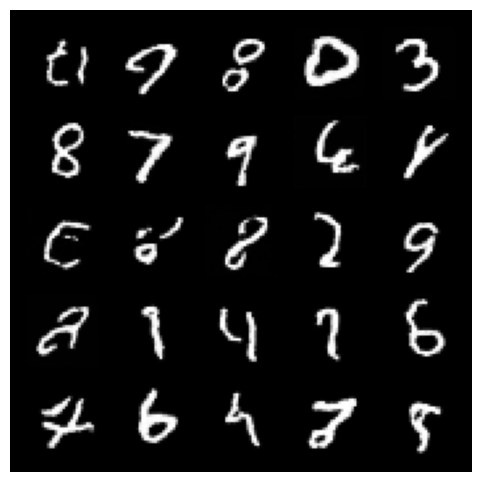

preds: [0, 9, 3, 0, 3, 8, 7, 9, 6, 8, 6, 5, 8, 2, 9, 2, 1, 4, 1, 8, 4, 6, 4, 3, 5]
confidences: [0.9988, 0.9266, 0.5801, 1.0, 1.0, 1.0, 1.0, 0.9994, 0.7128, 0.6642, 0.619, 0.7712, 0.9662, 1.0, 1.0, 0.8636, 0.975, 1.0, 0.6416, 0.8525, 0.7015, 1.0, 1.0, 0.4636, 0.7918]


In [8]:
# load DDPM samples and classify them
DDPM_SAMPLES_PATH = "./ddpm_samples_raw_identity.pt"   # change if you want identity samples instead

if os.path.exists(DDPM_SAMPLES_PATH):
    ddpm_samples_raw = torch.load(DDPM_SAMPLES_PATH, map_location="cpu")
    clf_loaded, clf_cfg, _ = load_classifier_checkpoint(CLF_CKPT_PATH, device=device)
    _ = classify_and_show_raw(
        model=clf_loaded,
        x_raw_m11=ddpm_samples_raw[:25],
        input_space=clf_cfg["input_space"],
        mnist_mean=clf_cfg["mnist_mean"],
        mnist_std=clf_cfg["mnist_std"],
        nrow=5,
    )
else:
    print("No DDPM samples file found at:", DDPM_SAMPLES_PATH)